# MODELING

For xG modeling, the best models are once that progressively answer “How much predictive power comes from nonlinear interactions beyond classical geometry?”

As such, I will focus on 5 models, namely: 
Logistic Regression, Random Forest(for a Nonlinear baseline), XGBoost(for a Strong tabular benchmark), CatBoost(Categorical-feature benchmark), and a simple CNN.


In [1]:
import pandas as pd

df = pd.read_csv('~/Desktop/Football_Stats/xG/datasets/shots.csv')
df.head()

,location,player,player_id,position,shot_aerial_won,shot_first_time,shot_statsbomb_xg,under_pressure,shot_open_goal,shot_follows_dribble,...,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle
0,"[94.5, 42.9]",Aaron Ramsey,3517.0,Right Wing,0,1,0.038832,0,0,0,...,0,0,0,0,1,0,94.5,42.9,25.664372,17.611035
1,"[93.5, 48.4]",Francesc Fàbregas i Soler,3478.0,Right Defensive Midfield,0,0,0.031541,1,0,0,...,0,0,0,0,1,0,93.5,48.4,27.799460,15.648789
2,"[89.8, 22.3]",Alexis Alejandro Sánchez Sánchez,3385.0,Left Wing,0,0,0.006660,1,0,0,...,0,0,0,0,1,0,89.8,22.3,35.004714,11.297814
3,"[98.2, 26.0]",Diego da Silva Costa,5198.0,Center Forward,0,0,0.022902,0,0,0,...,0,0,0,0,1,0,98.2,26.0,25.908300,14.904419
4,"[105.7, 24.2]",Theo Walcott,3668.0,Center Forward,0,0,0.049741,0,0,0,...,0,0,0,0,1,0,105.7,24.2,21.310326,14.633756


In [2]:
df.columns

Index(['location', 'player', 'player_id', 'position', 'shot_aerial_won',
       'shot_first_time', 'shot_statsbomb_xg', 'under_pressure',
       'shot_open_goal', 'shot_follows_dribble', 'goal', 'shot_body_part_Head',
       'shot_body_part_Left Foot', 'shot_body_part_Other',
       'shot_body_part_Right Foot', 'shot_technique_Backheel',
       'shot_technique_Diving Header', 'shot_technique_Half Volley',
       'shot_technique_Lob', 'shot_technique_Normal',
       'shot_technique_Overhead Kick', 'shot_technique_Volley',
       'shot_type_Corner', 'shot_type_Free Kick', 'shot_type_Open Play',
       'shot_type_Penalty', 'x', 'y', 'distance', 'angle'],
      dtype='object')

In [3]:
y = df['goal']
X = df.drop(['player', 'player_id', 'position', 'goal', 'shot_statsbomb_xg'], axis=1)

print(f"{X.shape}, {y.shape}")

(9908, 25), (9908,)


In [4]:
from sklearn.preprocessing import MinMaxScaler # Or StandardScaler

cols_to_normalize = ['distance', 'angle']

scaler = MinMaxScaler()
X[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

X.head()

,location,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,...,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle
0,"[94.5, 42.9]",0,1,0,0,0,0,1,0,0,...,0,0,0,0,1,0,94.5,42.9,0.381953,0.109927
1,"[93.5, 48.4]",0,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,93.5,48.4,0.414913,0.097636
2,"[89.8, 22.3]",0,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,89.8,22.3,0.526142,0.070383
3,"[98.2, 26.0]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,98.2,26.0,0.385719,0.092974
4,"[105.7, 24.2]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,105.7,24.2,0.314739,0.091278


Run the following code if you don't have scikit-learn installed in your environment

In [5]:
# %conda install -c conda-forge scikit-learn

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.head()

,location,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,...,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,x,y,distance,angle
3333,"[96.4, 45.5]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,96.4,45.5,0.359848,0.114180
2166,"[87.6, 43.3]",0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,87.6,43.3,0.488520,0.086901
8009,"[103.6, 21.5]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,103.6,21.5,0.367416,0.077479
8299,"[90.9, 32.2]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,90.9,32.2,0.450847,0.091271
2825,"[62.9, 25.3]",0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,62.9,25.3,0.895973,0.046719


In [7]:
X_train.drop(['location','x','y'], axis=1, inplace=True)
cordinates = X_test[['x', 'y']] # for model visualizations
X_test.drop(['location','x','y'], axis=1, inplace=True)

X_train.head()

,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,shot_technique_Backheel,...,shot_technique_Lob,shot_technique_Normal,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,distance,angle
3333,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0.359848,0.114180
2166,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,1,0,0.488520,0.086901
8009,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0.367416,0.077479
8299,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0.450847,0.091271
2825,0,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0.895973,0.046719


In [8]:
cordinates.shape

(2973, 2)

## LOGISTIC REGRESSION

In [9]:
from sklearn.linear_model import LogisticRegression

logistic_regressor = LogisticRegression(max_iter=1000)
logistic_regressor.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_log= logistic_regressor.predict_proba(X_test)[:,1]
y_log[:10]

array([0.02571504, 0.06432685, 0.0376824 , 0.05263498, 0.10926375,
       0.0534634 , 0.02896865, 0.02881436, 0.31214016, 0.16808732])

In [11]:
log_df = X_test.copy()
log_df['xG'] = y_log
log_df.iloc[830]

shot_aerial_won                 0.000000
shot_first_time                 0.000000
under_pressure                  0.000000
shot_open_goal                  0.000000
shot_follows_dribble            0.000000
shot_body_part_Head             0.000000
shot_body_part_Left Foot        0.000000
shot_body_part_Other            0.000000
shot_body_part_Right Foot       1.000000
shot_technique_Backheel         0.000000
shot_technique_Diving Header    0.000000
shot_technique_Half Volley      0.000000
shot_technique_Lob              0.000000
shot_technique_Normal           1.000000
shot_technique_Overhead Kick    0.000000
shot_technique_Volley           0.000000
shot_type_Corner                0.000000
shot_type_Free Kick             0.000000
shot_type_Open Play             1.000000
shot_type_Penalty               0.000000
distance                        0.358252
angle                           0.093267
xG                              0.047940
Name: 447, dtype: float64

In [12]:
log_df.iloc[100]

shot_aerial_won                 0.000000
shot_first_time                 0.000000
under_pressure                  0.000000
shot_open_goal                  0.000000
shot_follows_dribble            0.000000
shot_body_part_Head             0.000000
shot_body_part_Left Foot        0.000000
shot_body_part_Other            0.000000
shot_body_part_Right Foot       1.000000
shot_technique_Backheel         0.000000
shot_technique_Diving Header    0.000000
shot_technique_Half Volley      0.000000
shot_technique_Lob              0.000000
shot_technique_Normal           1.000000
shot_technique_Overhead Kick    0.000000
shot_technique_Volley           0.000000
shot_type_Corner                0.000000
shot_type_Free Kick             0.000000
shot_type_Open Play             1.000000
shot_type_Penalty               0.000000
distance                        0.424056
angle                           0.098763
xG                              0.033336
Name: 39, dtype: float64

## RANDOM FOREST

In [13]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
# try tuning parameters
# compre overall accuracy 
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
y_rf = random_forest.predict_proba(X_test)[:,1]
y_rf[:10]

array([0.  , 0.  , 0.  , 0.02, 0.13, 0.21, 0.  , 0.11, 0.61, 0.04])

In [15]:
rf_df = pd.DataFrame()
rf_df['Goal'] = y_test.copy()
rf_df['xG'] = y_rf
rf_df.iloc[830]

Goal    0.00
xG      0.15
Name: 447, dtype: float64

In [16]:
rf_df.iloc[100]

Goal    0.0
xG      0.0
Name: 39, dtype: float64

## XGBOOST

Run the following code if you don't have xgboost installed in your environment

In [17]:
# % conda install -c conda-forge xgboost

In [18]:
import xgboost as xgb

In [19]:
xgb = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective='binary:logistic'
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [20]:
y_xgb = xgb.predict_proba(X_test)[:,1]

In [21]:
xgb_df = pd.DataFrame()
xgb_df['Goal'] = y_test.copy()
xgb_df['xG'] = y_rf
xgb_df.iloc[830]

Goal    0.00
xG      0.15
Name: 447, dtype: float64

In [22]:
xgb_df.iloc[100]

Goal    0.0
xG      0.0
Name: 39, dtype: float64

## CATBOOST

Run the following code if you don't have CatBoost installed in your environment

In [23]:
# %conda install -c conda-forge catboost

In [24]:
from catboost import CatBoostClassifier

In [25]:
catBoost = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    verbose=10
)

catBoost.fit(X_train, y_train)

0:	learn: 0.5934373	total: 96.4ms	remaining: 9.54s
10:	learn: 0.2970757	total: 134ms	remaining: 1.08s
20:	learn: 0.2672002	total: 160ms	remaining: 603ms
30:	learn: 0.2597777	total: 183ms	remaining: 407ms
40:	learn: 0.2562044	total: 199ms	remaining: 287ms
50:	learn: 0.2538118	total: 214ms	remaining: 205ms
60:	learn: 0.2516650	total: 232ms	remaining: 148ms
70:	learn: 0.2495578	total: 300ms	remaining: 123ms
80:	learn: 0.2465438	total: 375ms	remaining: 88.1ms
90:	learn: 0.2442372	total: 430ms	remaining: 42.6ms
99:	learn: 0.2425469	total: 454ms	remaining: 0us


In [26]:
y_cat = catBoost.predict_proba(X_test)[:,1]

In [27]:
cat_df = pd.DataFrame()
cat_df['Goal'] = y_test.copy()
cat_df['xG'] = y_cat
cat_df.iloc[830]

Goal    0.000000
xG      0.030186
Name: 447, dtype: float64

In [28]:
cat_df.iloc[100]

Goal    0.000000
xG      0.026081
Name: 39, dtype: float64

Foundation Model: TabPFN

In [29]:
# %conda install -c conda-forge tabpfn 
# %conda install -c conda-forge tabpfn-client
# %pip install tabpfn-client

or use mine: "tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs"

In [30]:
# import os

# os.environ["TABPFN_TOKEN"] = "tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs"

In [31]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token("tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs")
tabPFN = TabPFNClassifier()
tabPFN.fit(X_train, y_train)
goal_tabPFN = tabPFN.predict(X_test)
y_tabPFN = tabPFN.predict_proba(X_test)[:,1]

00:03 Fitting... Done!
00:02 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!


In [ ]:
y_tabPFN = tabPFN.predict_proba(X_test)[:,1]

# MODEL EVAULATION

For Logistic Regression

In [33]:
log_df.sort_values(by='xG', ascending=False).head()

,shot_aerial_won,shot_first_time,under_pressure,shot_open_goal,shot_follows_dribble,shot_body_part_Head,shot_body_part_Left Foot,shot_body_part_Other,shot_body_part_Right Foot,shot_technique_Backheel,...,shot_technique_Normal,shot_technique_Overhead Kick,shot_technique_Volley,shot_type_Corner,shot_type_Free Kick,shot_type_Open Play,shot_type_Penalty,distance,angle,xG
1369,0,1,0,1,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0.020766,0.805168,0.897808
9725,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0.026552,0.819744,0.891373
9284,0,0,0,1,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0.031821,0.720166,0.849730
3931,0,1,0,1,0,0,1,0,0,0,...,1,0,0,0,0,1,0,0.038004,0.667722,0.846318
9269,0,1,1,1,0,0,1,0,0,0,...,0,0,1,0,0,1,0,0.028771,0.850506,0.841178


In [34]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss, accuracy_score

print(f"Log Loss: {log_loss(y_test, y_log):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_log):.3f}\nBrier Score: {brier_score_loss(y_test, y_log):.3f}")

Log Loss: 0.272
ROC_AUC Score: 0.776
Brier Score: 0.076


For Random Forest

In [ ]:
print(f"**Log Loss: {log_loss(y_test, y_rf):.3f}**\nROC_AUC Score: {roc_auc_score(y_test, y_rf):.3f}\nBrier Score: {brier_score_loss(y_test, y_rf):.3f}")

Log Loss: 0.825
ROC_AUC Score: 0.704
Brier Score: 0.089


For XGBoost

In [36]:
print(f"Log Loss: {log_loss(y_test, y_xgb):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_xgb):.3f}\nBrier Score: {brier_score_loss(y_test, y_xgb):.3f}")

Log Loss: 0.272
ROC_AUC Score: 0.774
Brier Score: 0.076


For CatBoost

In [37]:
print(f"Log Loss: {log_loss(y_test, y_cat):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_cat):.3f}\nBrier Score: {brier_score_loss(y_test, y_cat):.3f}")

Log Loss: 0.270
ROC_AUC Score: 0.780
Brier Score: 0.076


TabPFN

In [38]:
# print(f"Accuracy: {accuracy_score(y_test, goal_tabPFN):.3f}\nLog Loss: {log_loss(y_test, y_tabPFN):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_tabPFN):.3f}\nBrier Score: {brier_score_loss(y_test, y_tabPFN):.3f}")
print(f"Log Loss: {log_loss(y_test, y_tabPFN):.3f}\nROC_AUC Score: {roc_auc_score(y_test, y_tabPFN):.3f}\nBrier Score: {brier_score_loss(y_test, y_tabPFN):.3f}")

Log Loss: 0.272
ROC_AUC Score: 0.780
Brier Score: 0.076


Calibration Curve

In [39]:
# %conda install -c conda-forge matplotlib

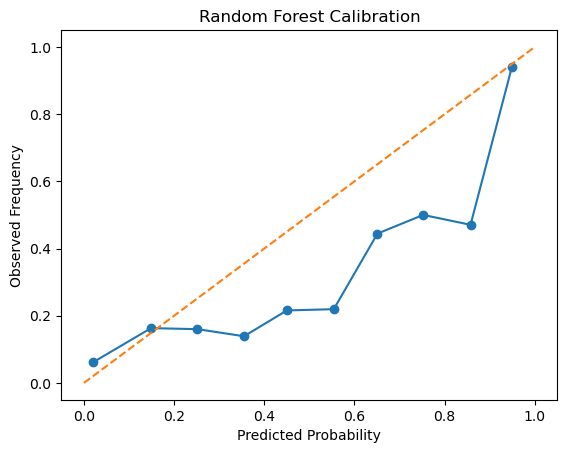

In [40]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_rf, prob_pred = calibration_curve(
    y_test,
    y_rf,
    n_bins=10
)

plt.plot(prob_pred, prob_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Random Forest Calibration")
plt.show()

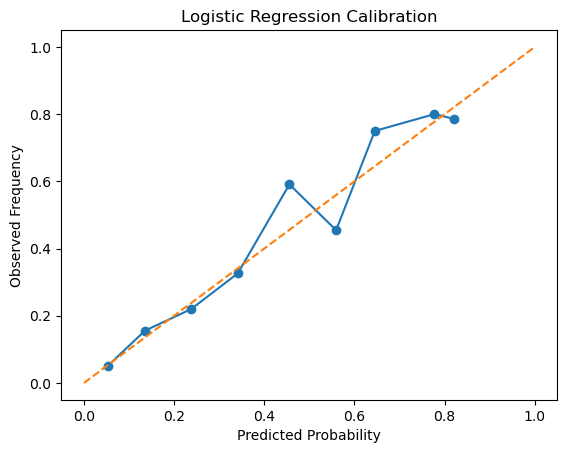

In [41]:
prob_rf, prob_pred = calibration_curve(
    y_test,
    y_log,
    n_bins=10
)

plt.plot(prob_pred, prob_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Logistic Regression Calibration")
plt.show()

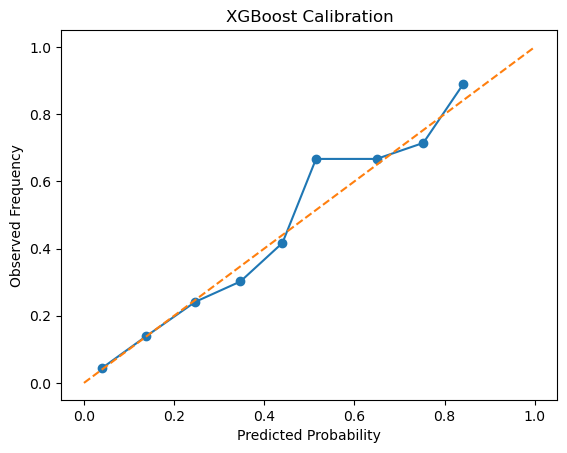

In [42]:
prob_xgb, prob_pred = calibration_curve(
    y_test,
    y_xgb,
    n_bins=10
)

plt.plot(prob_pred, prob_xgb, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("XGBoost Calibration")
plt.show()

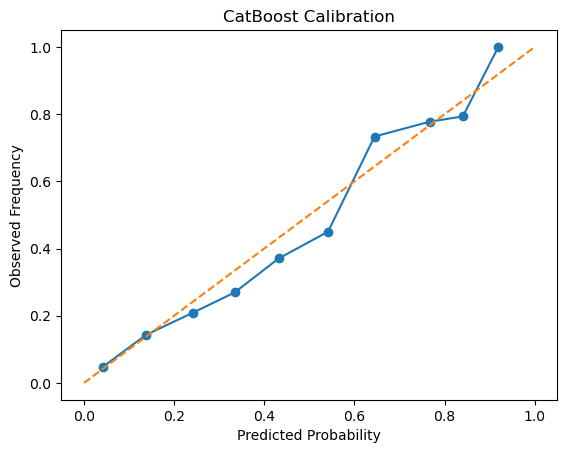

In [43]:
prob_cat, prob_pred = calibration_curve(
    y_test,
    y_cat,
    n_bins=10
)

plt.plot(prob_pred, prob_cat, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("CatBoost Calibration")
plt.show()

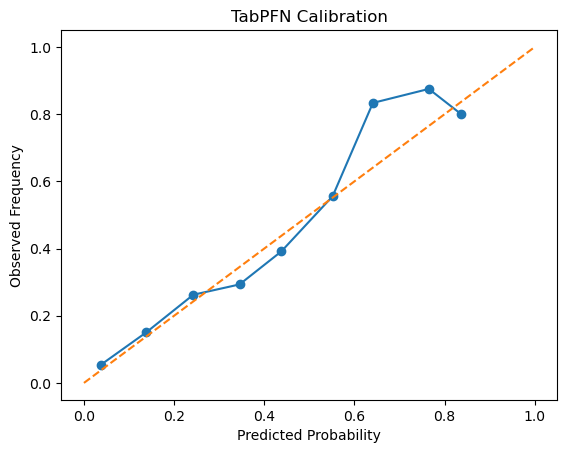

In [44]:
prob_rf, prob_pred = calibration_curve(
    y_test,
    y_tabPFN,
    n_bins=10
)

plt.plot(prob_pred, prob_rf, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("TabPFN Calibration")
plt.show()

## Feature Importance

In [45]:
importance = pd.Series(
    random_forest.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

angle                           0.432112
distance                        0.420039
shot_type_Penalty               0.027090
shot_open_goal                  0.018234
under_pressure                  0.014104
shot_first_time                 0.012175
shot_type_Open Play             0.011942
shot_body_part_Right Foot       0.009842
shot_technique_Normal           0.008750
shot_body_part_Head             0.008281
shot_technique_Half Volley      0.006160
shot_aerial_won                 0.006080
shot_body_part_Left Foot        0.005710
shot_technique_Volley           0.005197
shot_type_Free Kick             0.002912
shot_technique_Lob              0.002415
shot_technique_Backheel         0.002337
shot_technique_Diving Header    0.002054
shot_technique_Overhead Kick    0.001496
shot_body_part_Other            0.001309
shot_follows_dribble            0.001153
shot_type_Corner                0.000608
dtype: float64


# MODEL VISUALIZATIONS

In [46]:
from mplsoccer import Pitch
from matplotlib.colors import LinearSegmentedColormap

pitch = Pitch(pitch_type='opta')
colors = ['red', 'yellow', 'green']
cmap = LinearSegmentedColormap.from_list('my_colormap', colors)
sc = pitch.scatter

In [47]:
# import numpy as np

# dataframes = {
#     'Logistic Regression': log_df,
#     'Random Forest': rf_df,
#     'XGBoost': xgb_df,
#     'CatBoost': cat_df
# }

# for name, df in dataframes.items():

#     fig, ax = pitch.draw(figsize=(10,8))
#     sc = pitch.scatter(
#         cordinates['x'], cordinates['y'], c=df['xG'],
#         cmap=cmap, edgecolors='black', linewidth=0.5, s=100, ax=ax
#     )

#     cbar = plt.colorbar(sc, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
#     cbar.set_label(f'{name} xG Probability')

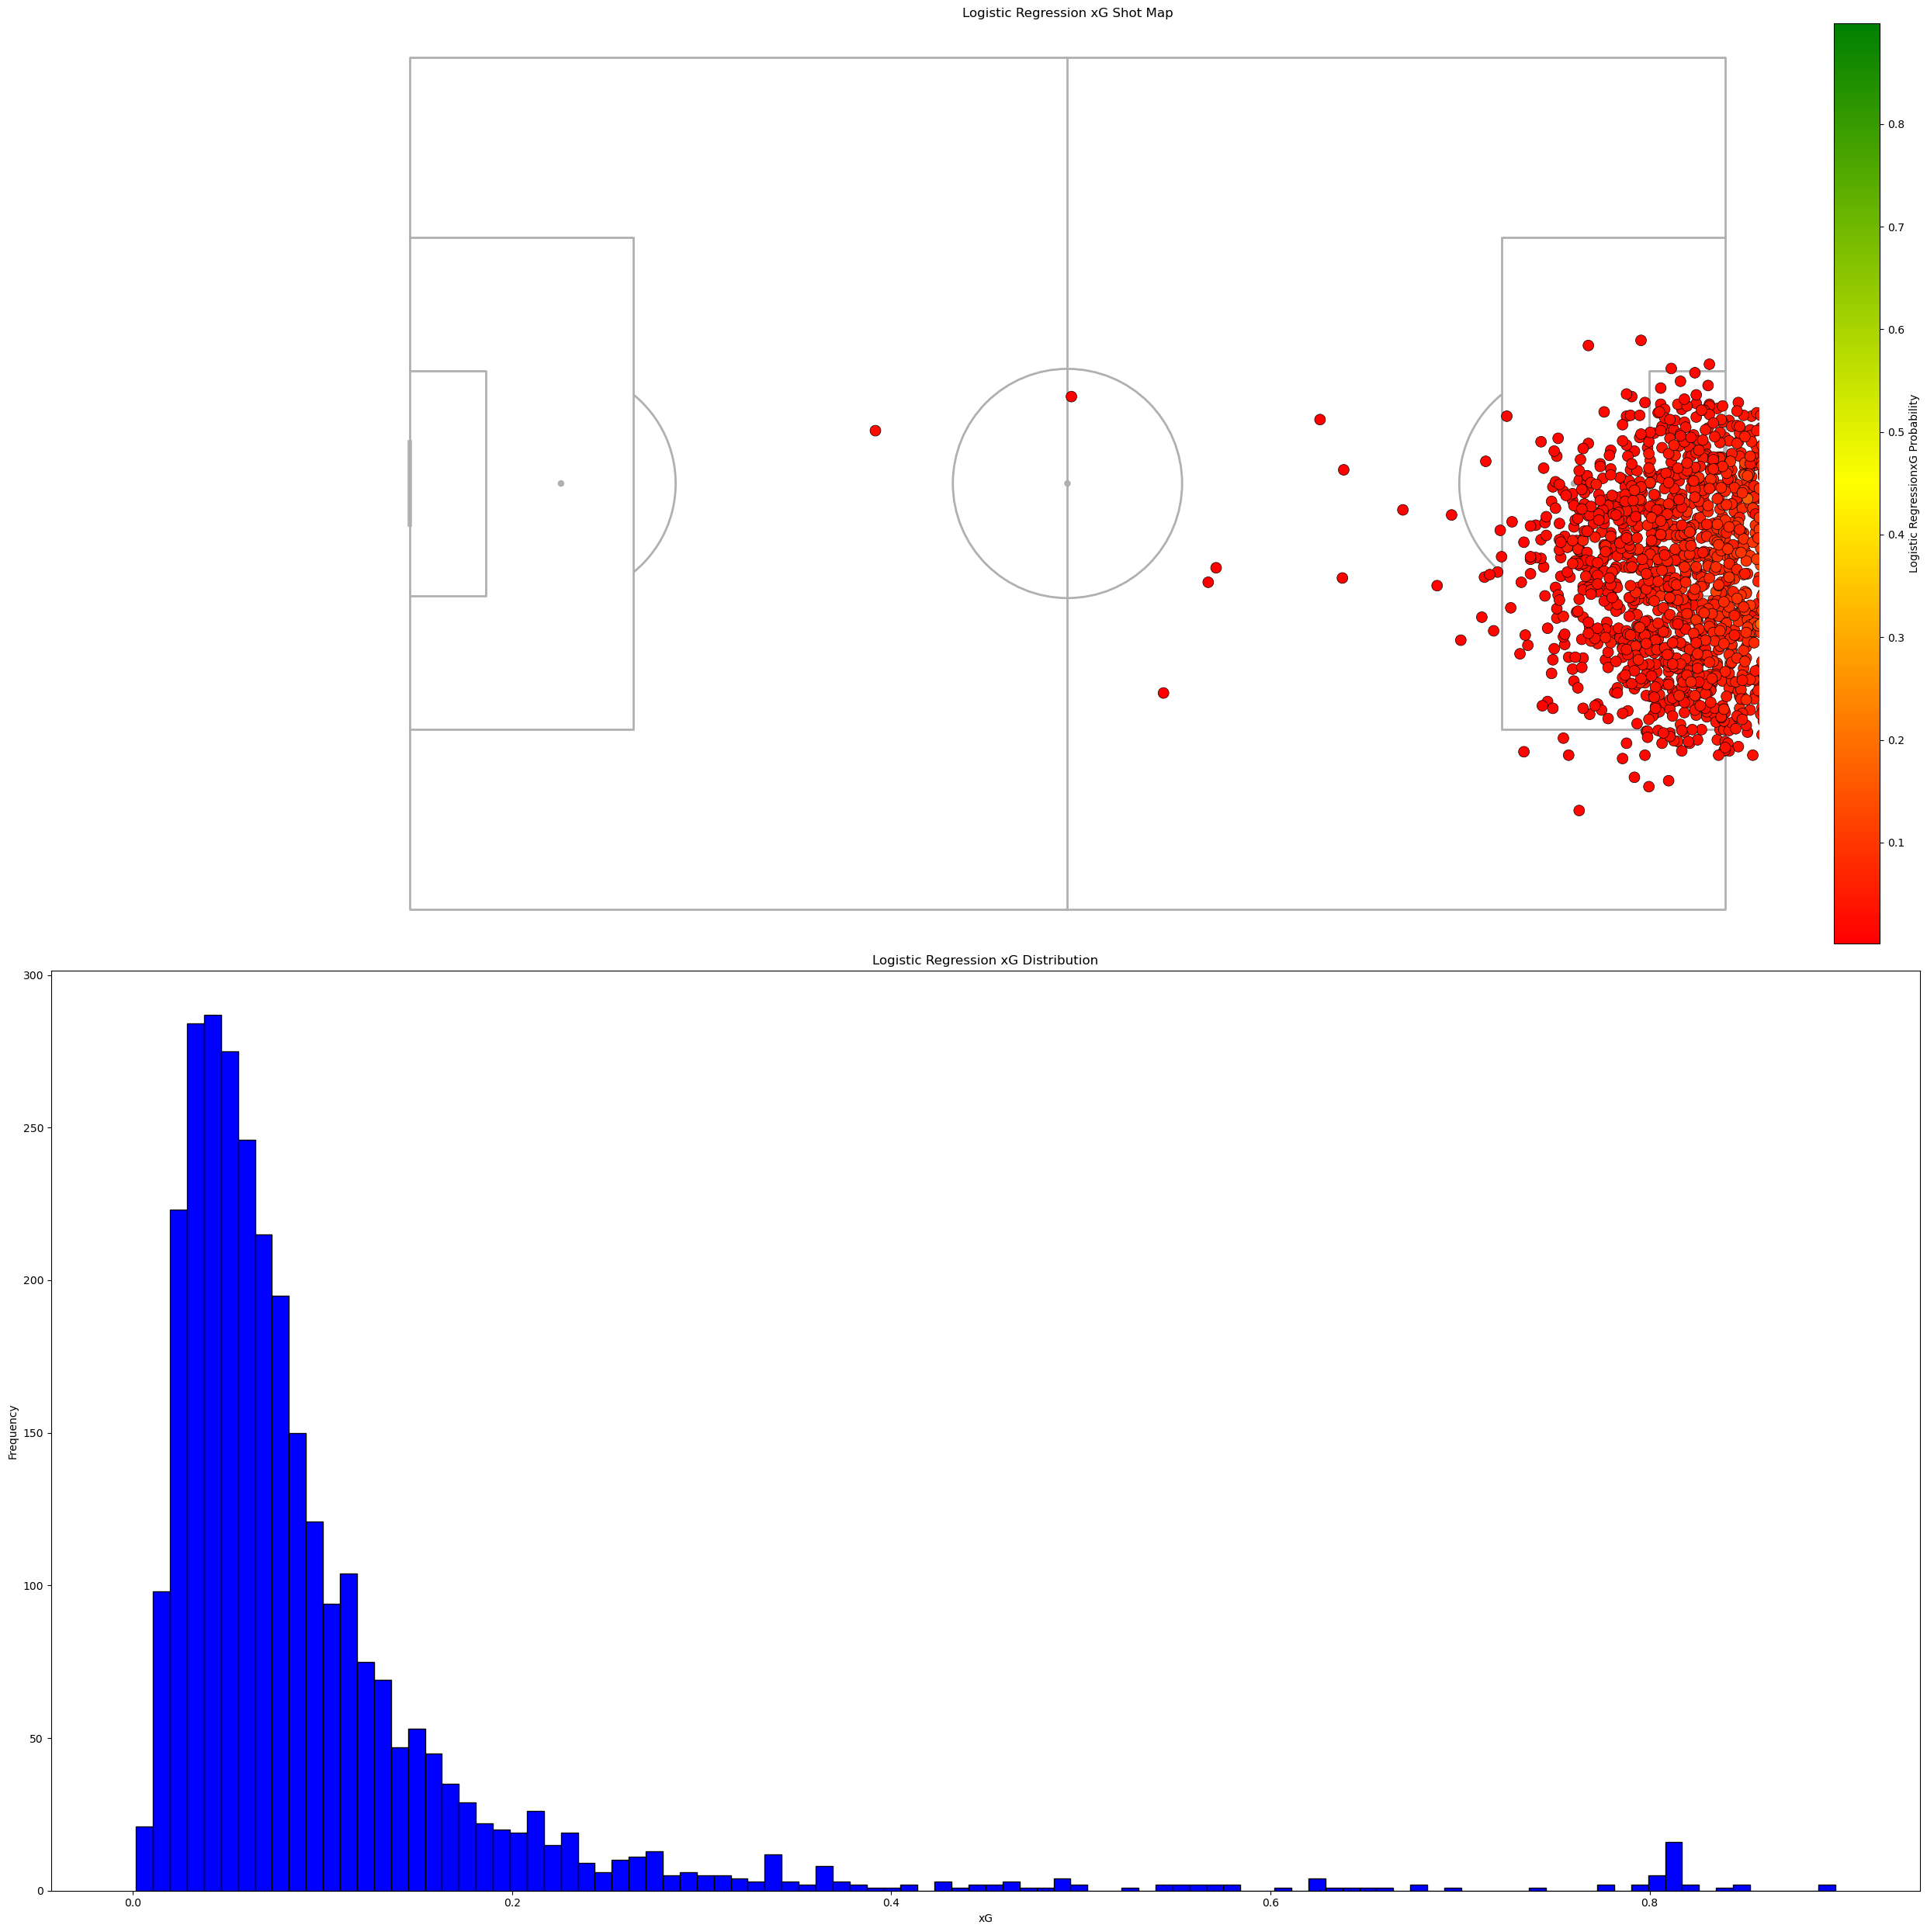

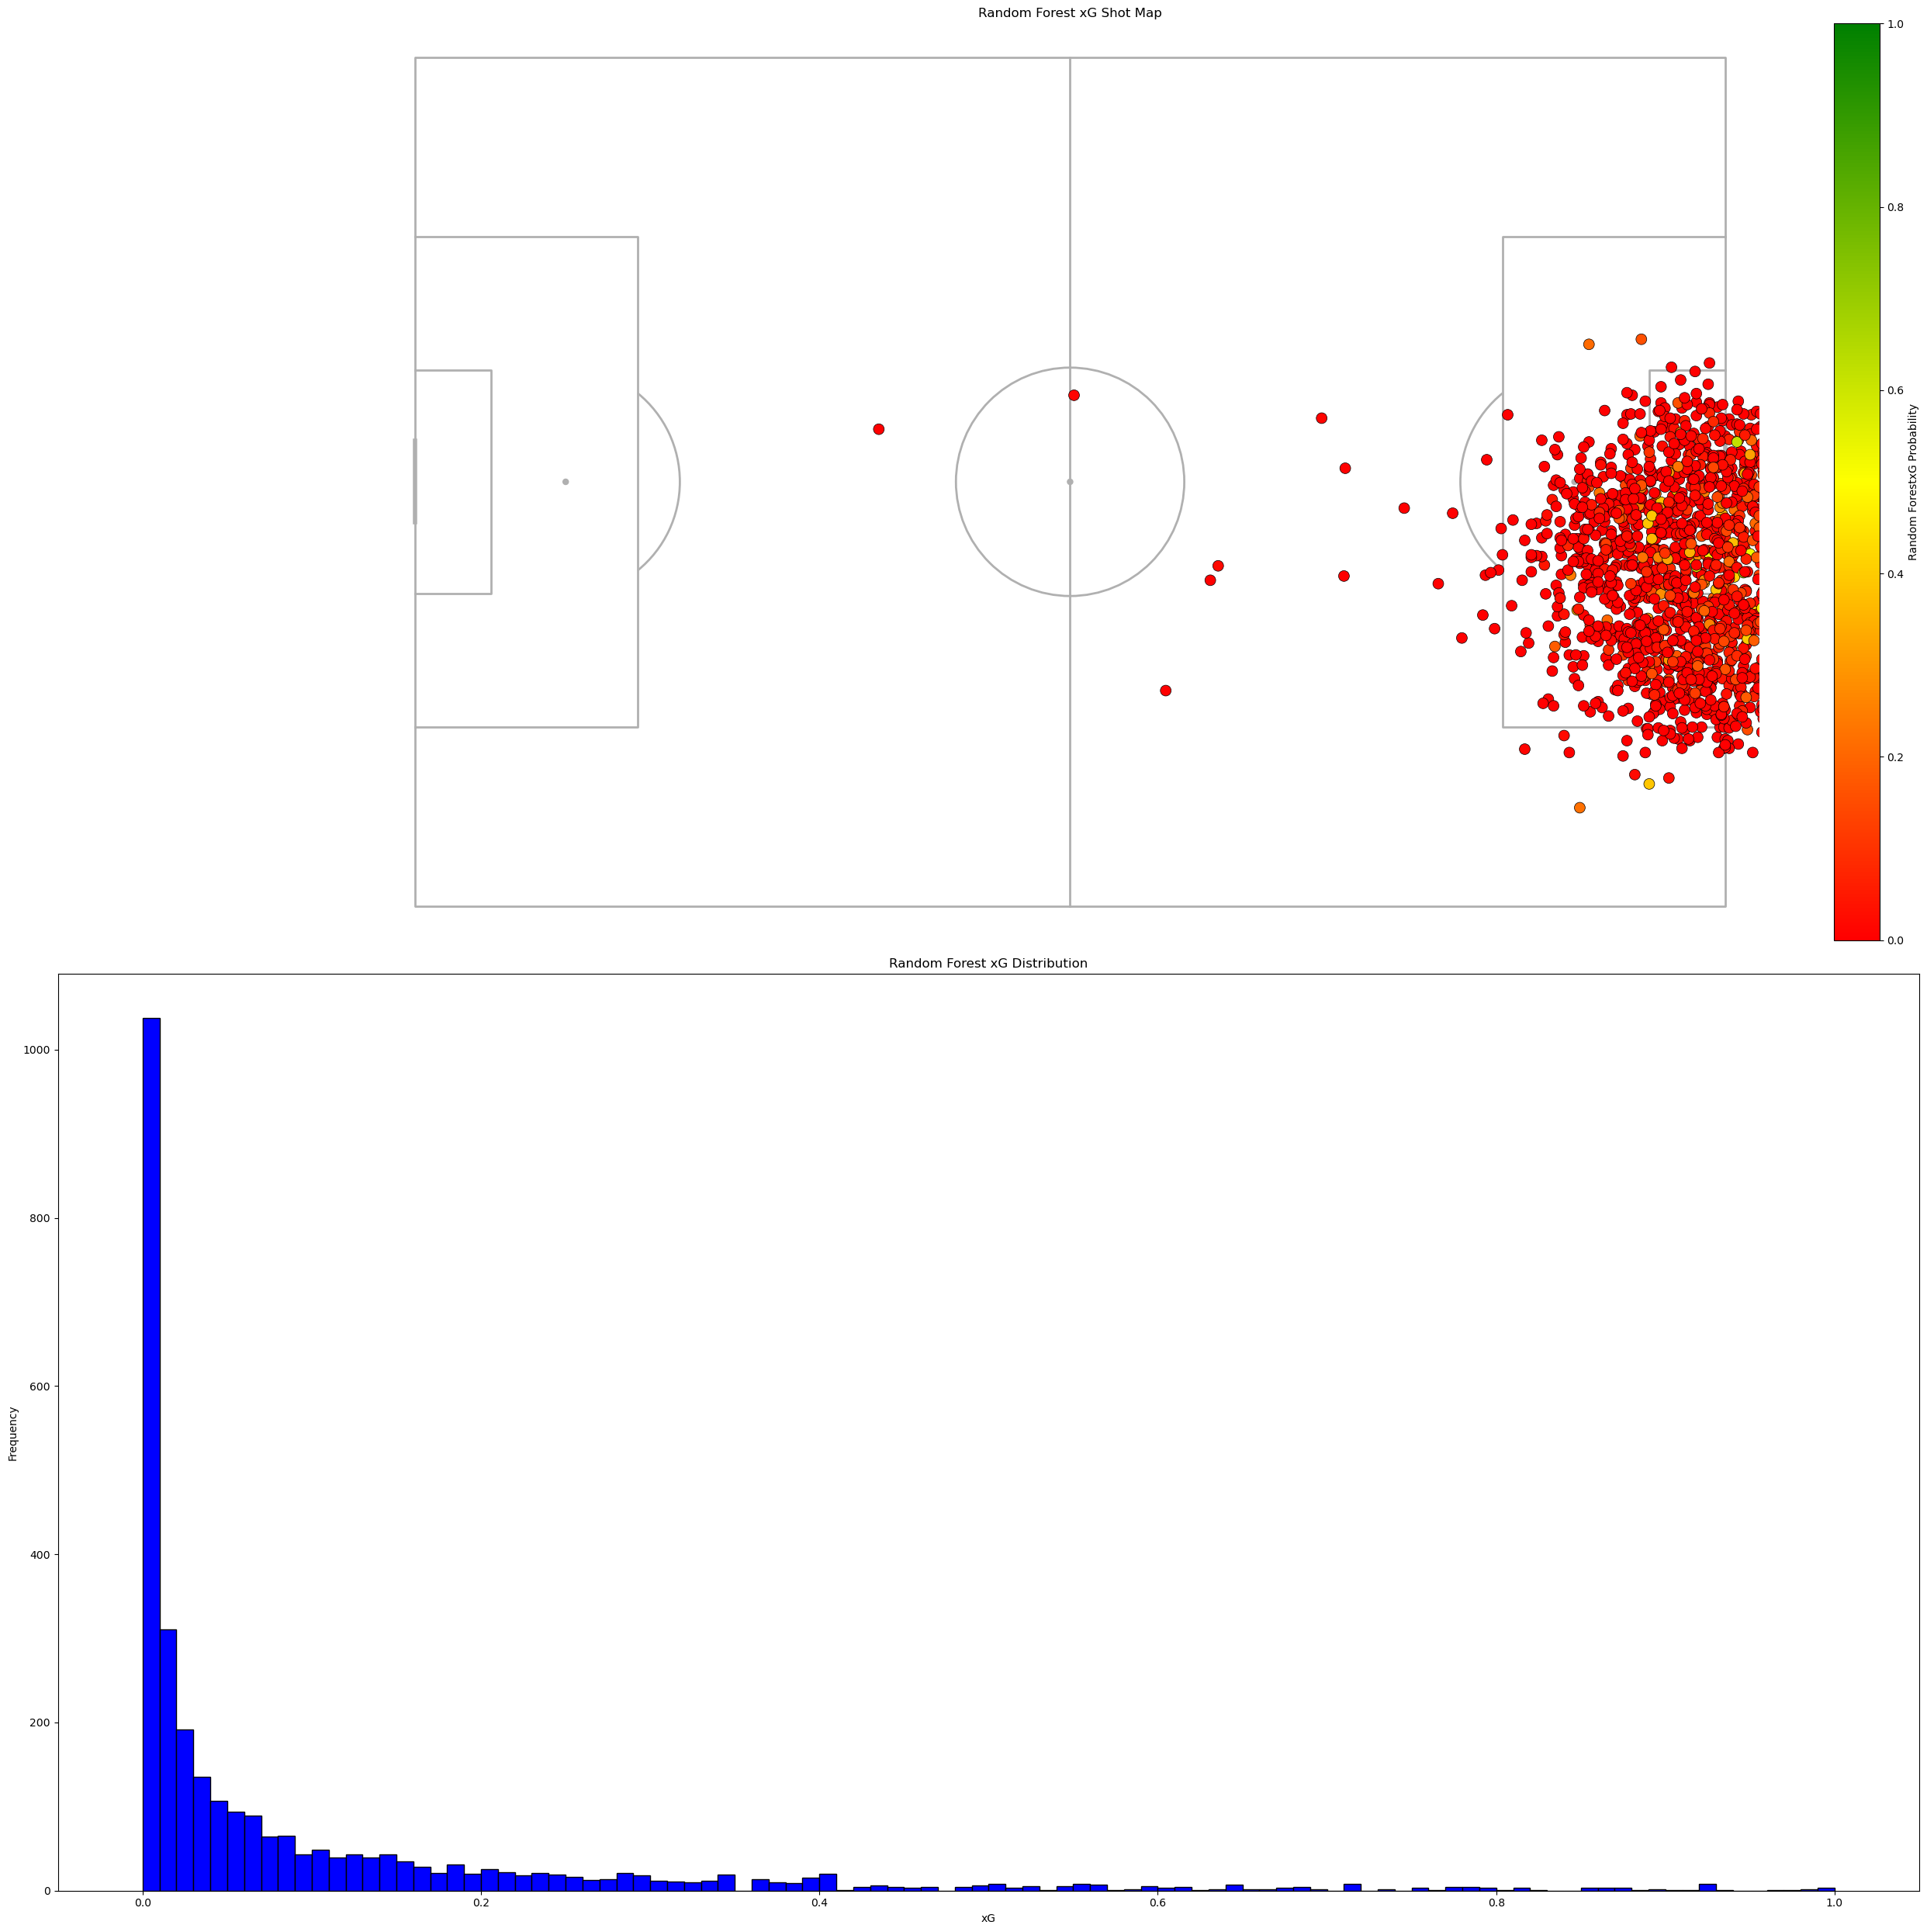

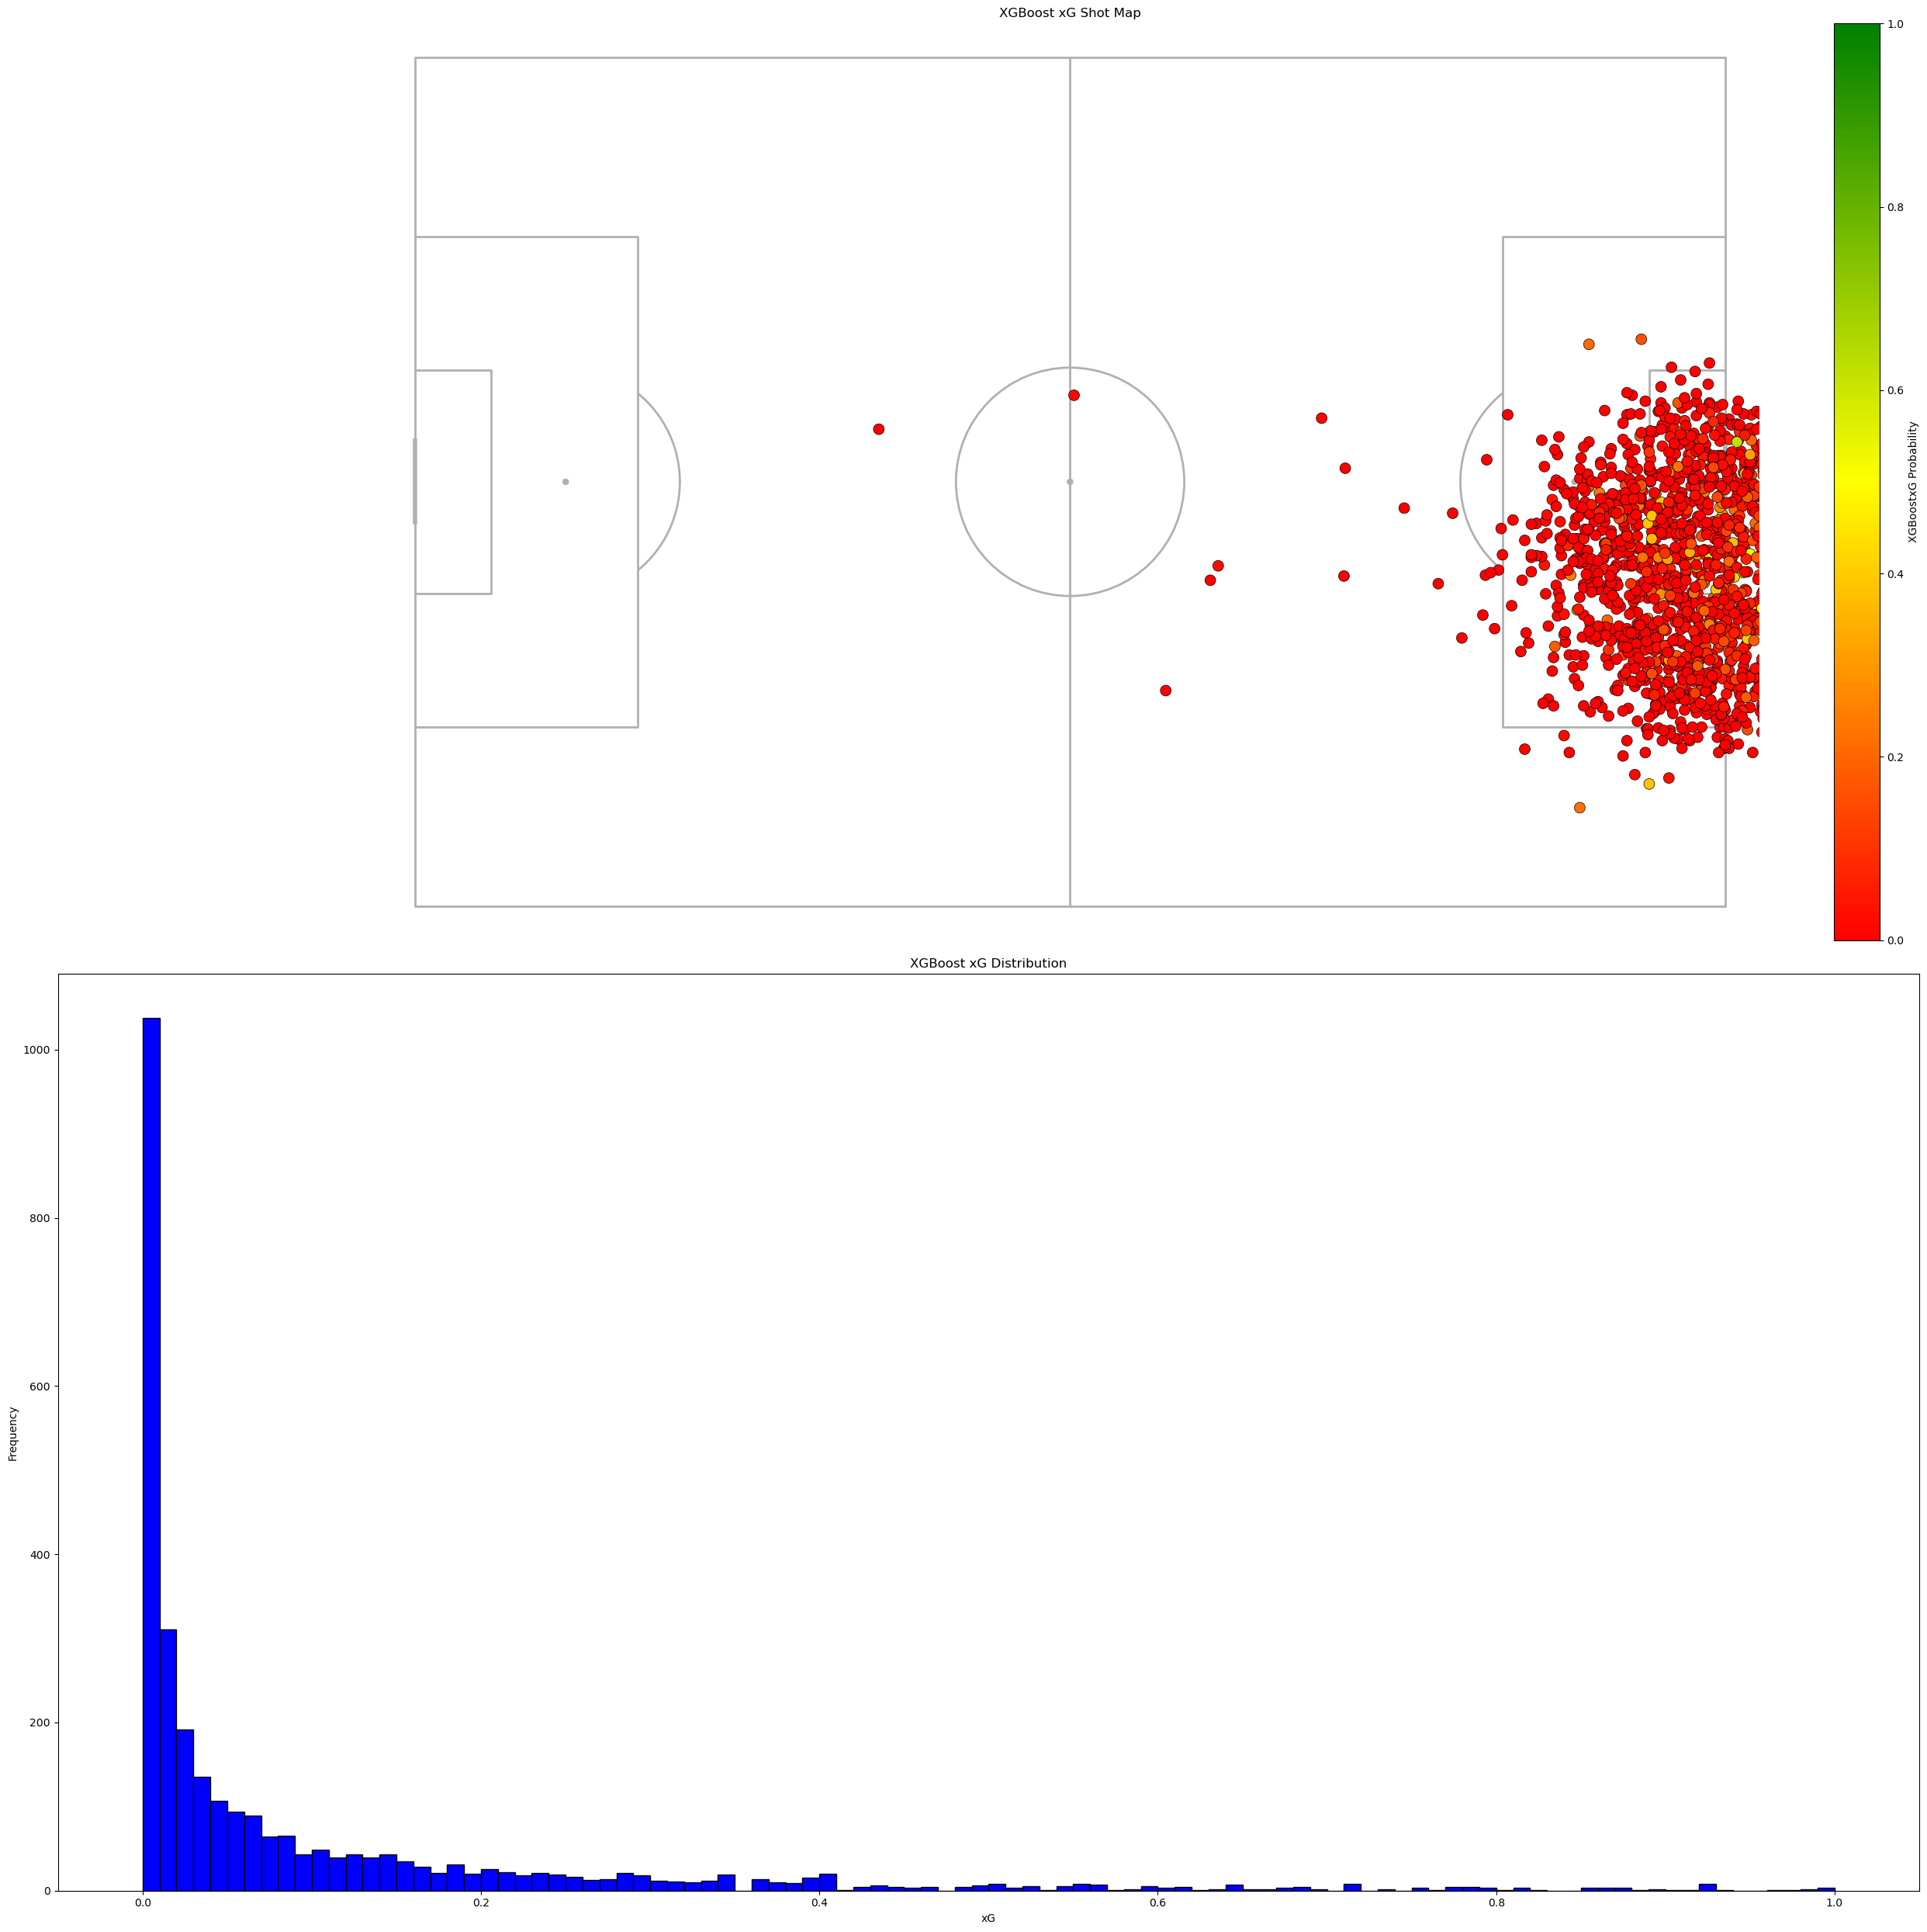

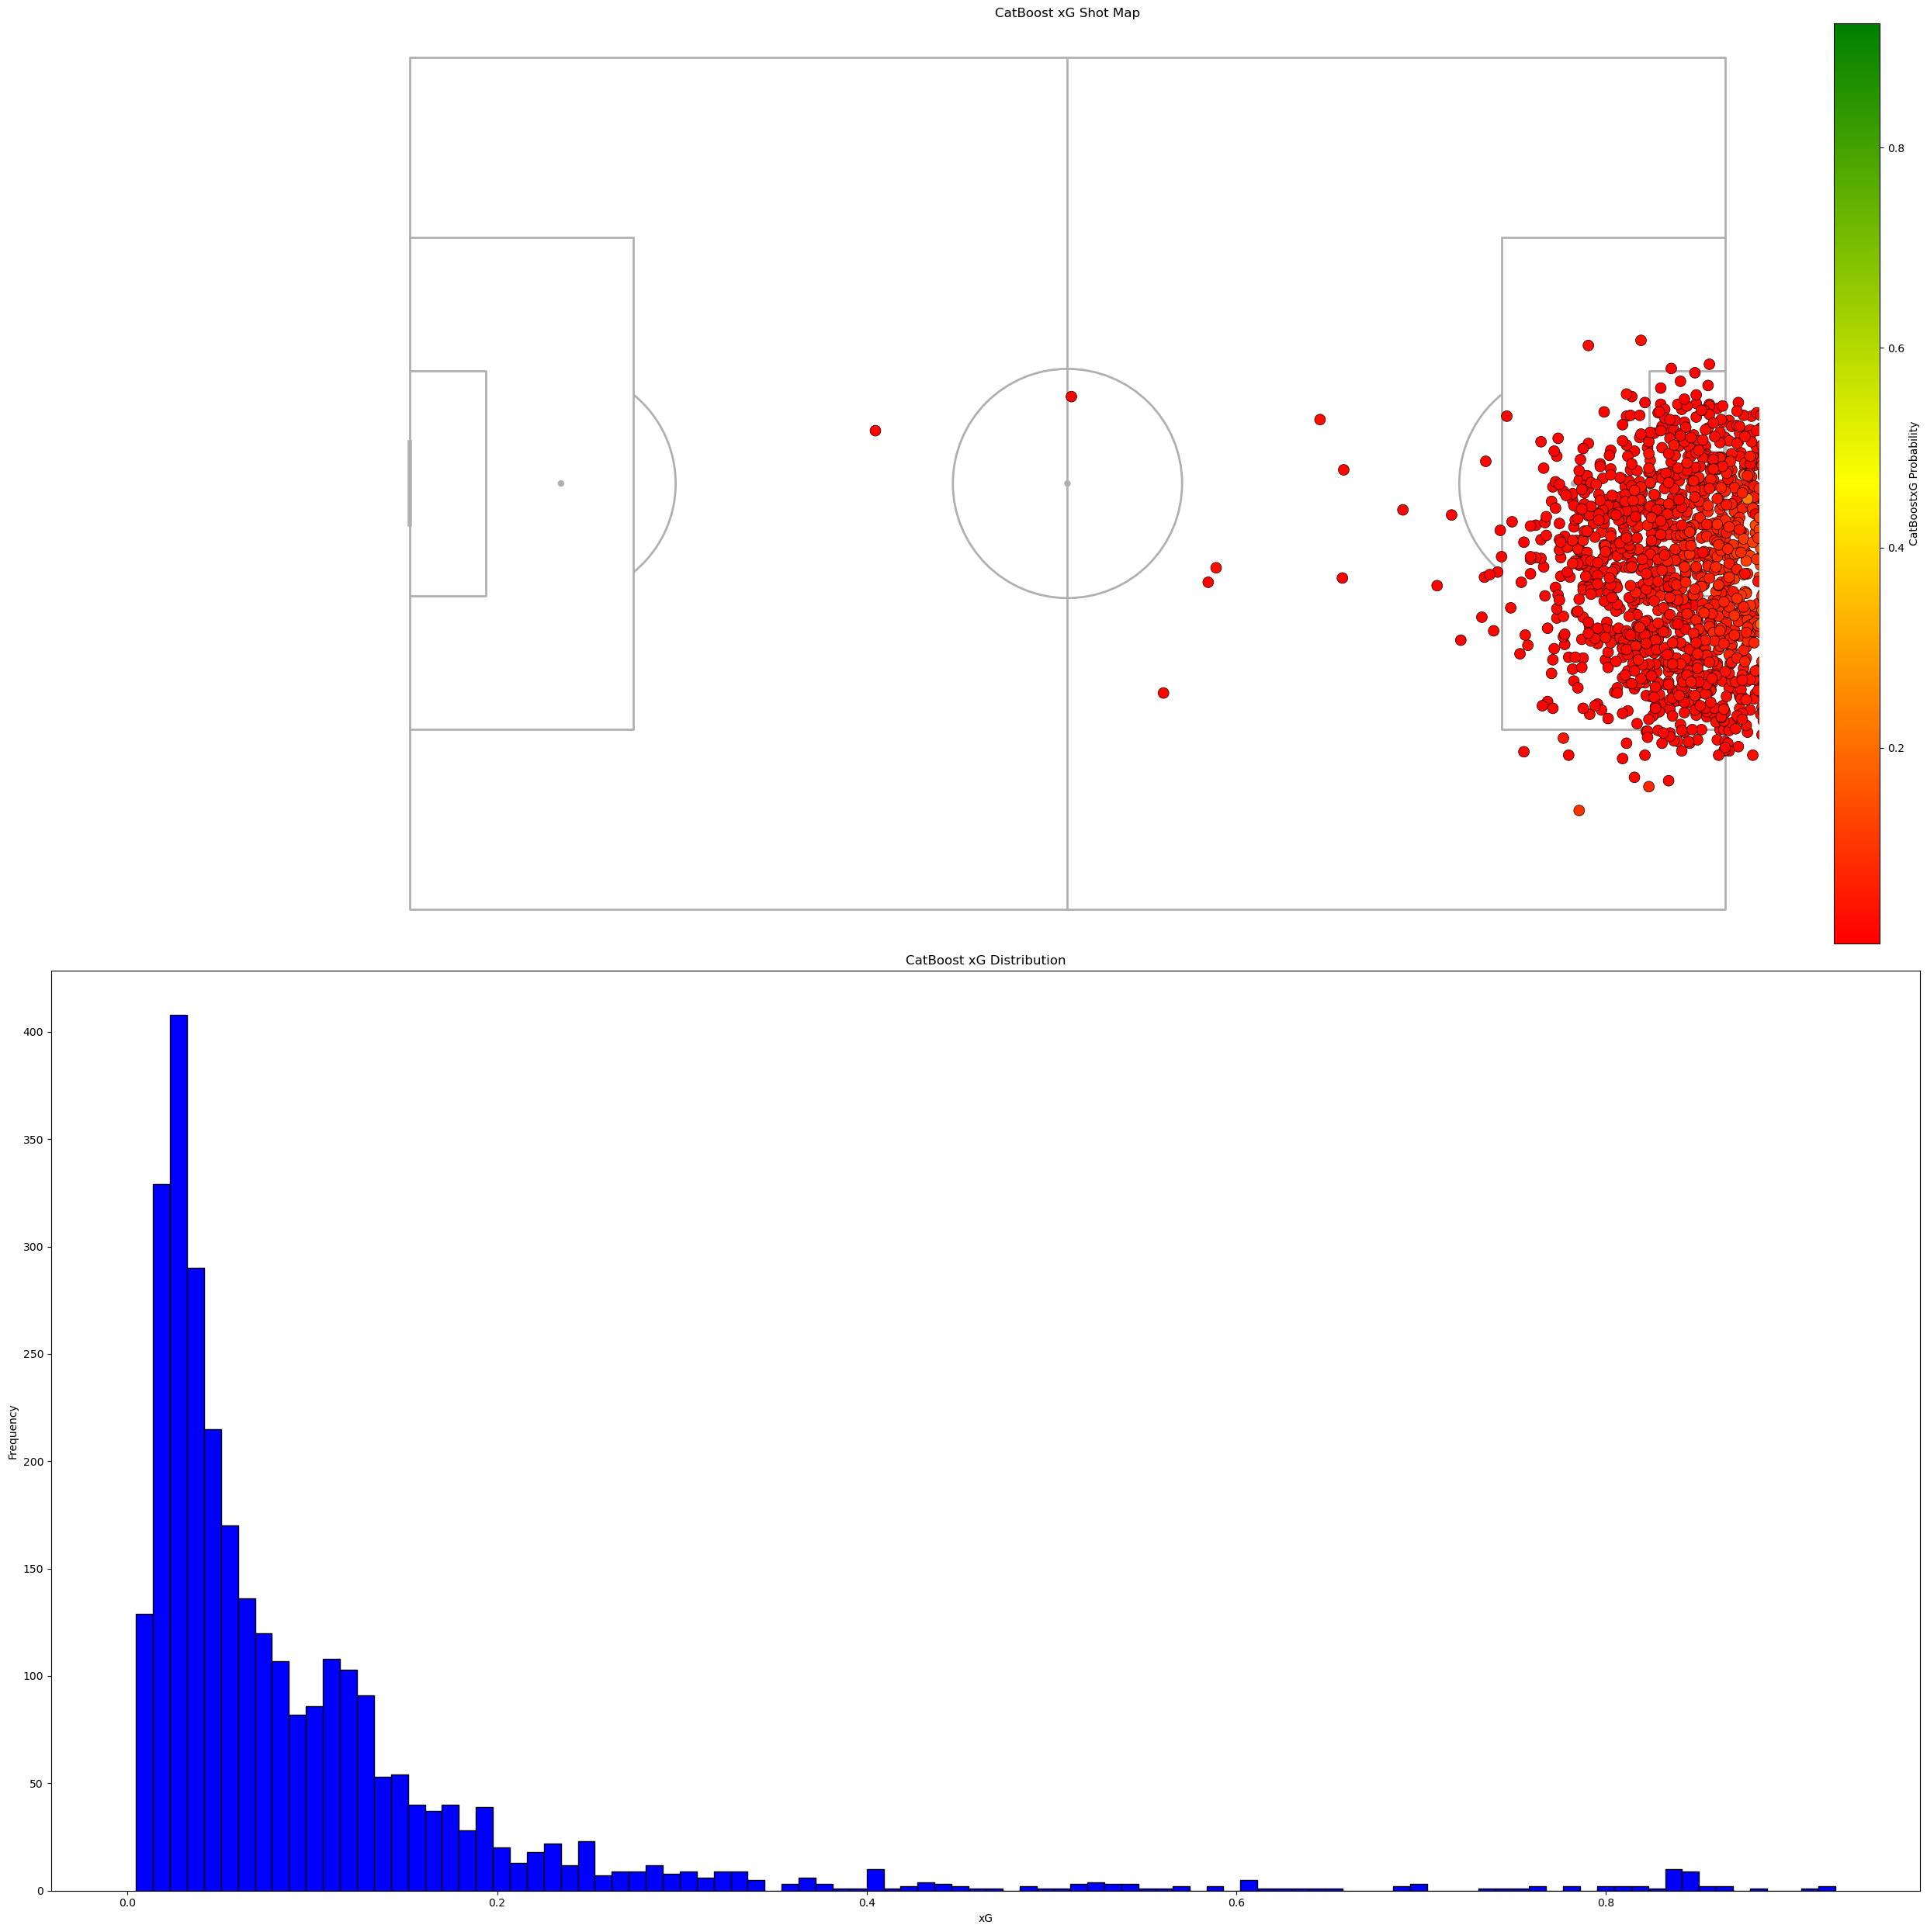

In [48]:
import matplotlib.pyplot as plt
import numpy as np

dataframes = {
    'Logistic Regression': log_df,
    'Random Forest': rf_df,
    'XGBoost': xgb_df,
    'CatBoost': cat_df
}

for name, df in dataframes.items():
    
    fig, axes = plt.subplots(2, 1, figsize=(25,25))

    # ---- TOP: Pitch Plot ----
    pitch.draw(ax=axes[0])
    
    sc = pitch.scatter(
        cordinates['x'], cordinates['y'],
        c=df['xG'],
        cmap=cmap,
        edgecolors='black',
        linewidth=0.5,
        s=100,
        ax=axes[0]
    )
    
    axes[0].set_title(f'{name} xG Shot Map')
    
    cbar = plt.colorbar(sc, ax=axes[0], fraction=0.046, pad=0.04)
    cbar.set_label(f'{name}xG Probability')
    
    # ---- BOTTOM: Histogram ----
    
    axes[1].hist(df['xG'], bins=100, color='blue', edgecolor='black')
    axes[1].set_title(f'{name} xG Distribution')
    axes[1].set_xlabel('xG')
    axes[1].set_ylabel('Frequency')
    
    
    plt.tight_layout()
    plt.show()